In [1]:
import pyemu
import os
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import shutil
import numpy as np
import sys
import swatmf

In [2]:
swatmf.__version__

'1.0.1'

# 01. Set working directory

In [3]:
# path to project directory
prj_dir = "C:\\Users\\seonggpa\\Documents\\projects\\watersheds\\hbasnet_opt"
main_opt_path = os.path.join(prj_dir, 'main_opt')
os.chdir(main_opt_path)

# 02. Create prior pst

In [4]:
# create prior pst based on reweigted control file
pst = pyemu.Pst('mb_pp_rw.pst')

In [8]:
# set prior UA
pst.pestpp_options['ies_drop_conflicts'] = True
pst.pestpp_options['ies_no_noise'] = True
pst.pestpp_options['ies_num_reals'] = 300 # number of realization
pst.control_data.noptmax = -1 # number of iteration
pst.model_command = 'python forward_run.py'
pst.write('koki_zon_rw_prior.pst', version=2) # write new IES control file

noptmax:-1, npar_adj:83, nnz_obs:5114


In [5]:
os.chdir(prj_dir)

In [6]:
os.getcwd()

'C:\\Users\\seonggpa\\Documents\\projects\\watersheds\\hbasnet_opt'

# 04. Run IES

## 04.1 Set up IES

In [7]:
# check number of cores on your computer
num_workers = psutil.cpu_count(logical=False)

In [8]:
# name for prior ua directory
m_d = os.path.join(prj_dir, "mb_pp_rw_prior")

## 04.2 Execute

In [19]:
pyemu.os_utils.start_workers(main_opt_path, # the folder which contains the "template" PEST dataset
                            'pestpp-ies', #the PEST software version we want to run
                            'mb_pp_rw_prior.pst', # the control file to use with PEST
                            num_workers=num_workers, #how many agents to deploy
                            worker_root=prj_dir, #where to deploy the agent directories; relative to where python is running
                            master_dir=m_d, #the manager directory,
                            # reuse_master=True
                            )

2026-05-15 05:00:13,104 - MainProcess - INFO - Reserved port 4458 for process 31080


# 05. Analyze results
## 05.1 Check model performance

In [9]:
# load prior simulation
pr_oe = pyemu.ObservationEnsemble.from_csv(
    pst=pst,filename=os.path.join(m_d,"mb_pp_rw_prior.0.obs.csv")
    )

In [10]:
# check phi values
pr_oe.phi_vector

real_name
0        11720.158736
1       693318.821069
2        39403.056849
3        12717.533492
4        33826.807877
            ...      
295     217208.253977
296     417697.088471
297      15901.779956
298      22698.012985
base    255408.252404
Length: 299, dtype: float64

## 05.2 Prior Predictive Uncertainty

In [11]:
from swatmf import analyzer

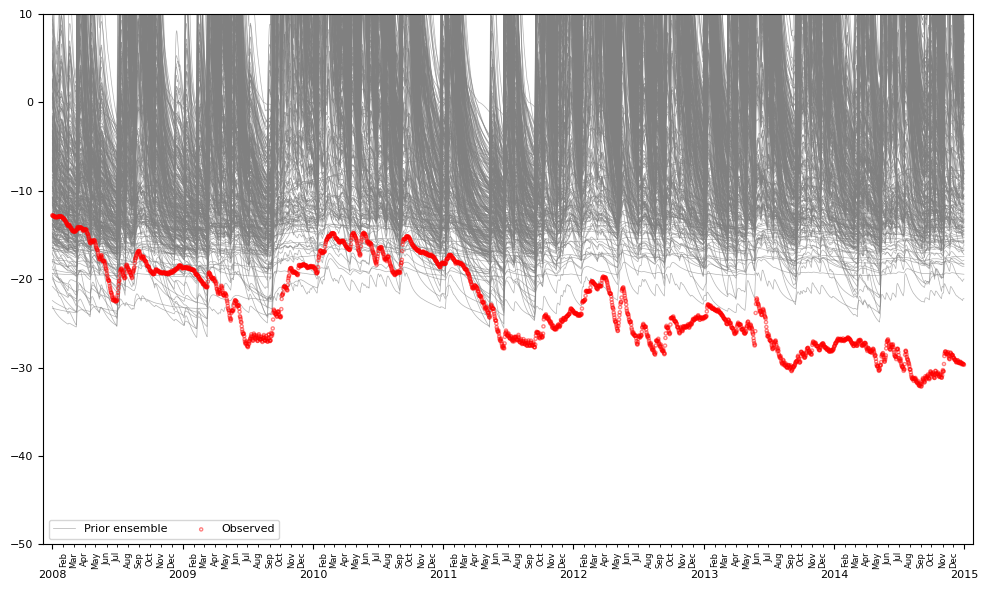

(<Figure size 1000x600 with 1 Axes>, <Axes: >)

In [12]:
analyzer.ua.plot_tseries_ensemble(pst, 'gid5163', pr_oe=pr_oe, height=6, dot=False, ymin=-50, ymax=10, show=True)

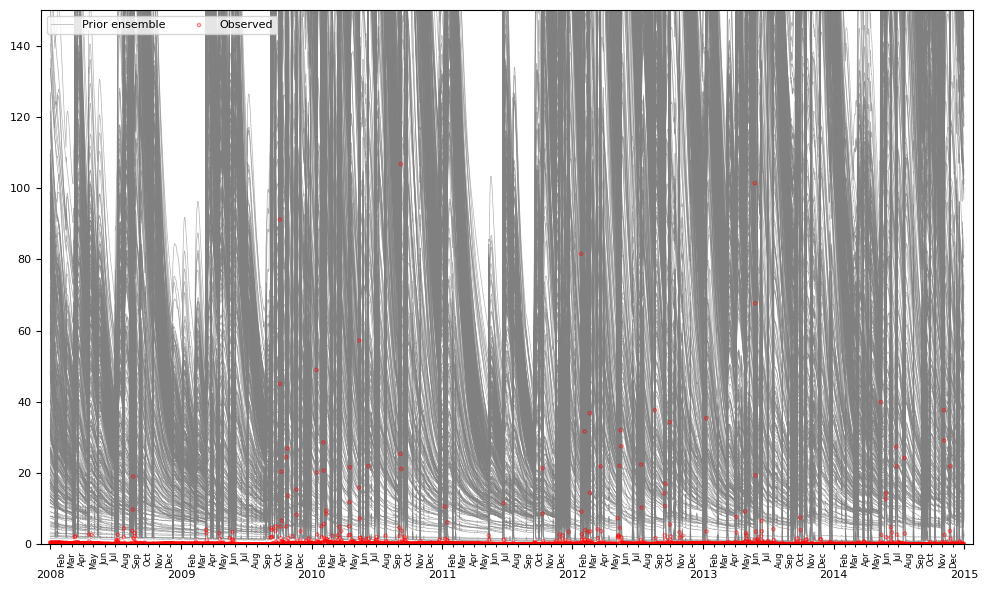

(<Figure size 1000x600 with 1 Axes>, <Axes: >)

In [13]:
analyzer.ua.plot_tseries_ensemble(pst, 'rch_01', pr_oe=pr_oe, height=6, dot=False, ymin=0, ymax=150, show=True)

## 05.3 Prior parameter probability

In [14]:
pr_pe = pyemu.ParameterEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,"mb_pp_rw_prior.{0}.par.csv".format(0)))

In [15]:
df_pars = pd.read_csv(os.path.join(m_d, "mb_pp_rw_prior.par_data.csv"))
sel_pars = df_pars.loc[df_pars["partrans"]=='log']
sel_pars

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,i,j,zone
0,adj_pkr,log,factor,1.00,0.1000,1.9,swat,1.0,-1.0,1,NaN,NaN,NaN
1,c_factor,log,factor,1.00,0.1000,1.9,swat,1.0,-1.0,1,NaN,NaN,NaN
2,canmx,log,factor,1.00,0.1000,1.9,swat,1.0,-1.0,1,NaN,NaN,NaN
3,ch_k1,log,factor,1.00,0.1000,1.9,swat,1.0,-1.0,1,NaN,NaN,NaN
4,ch_n1,log,factor,1.00,0.1000,1.9,swat,1.0,-1.0,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,sy0_i:65_j:55_zone:1,log,factor,0.01,0.0001,0.6,sy,1.0,0.0,1,65.0,55.0,1.0
110,sy0_i:75_j:55_zone:1,log,factor,0.01,0.0001,0.6,sy,1.0,0.0,1,75.0,55.0,1.0
111,sy0_i:85_j:45_zone:1,log,factor,0.01,0.0001,0.6,sy,1.0,0.0,1,85.0,45.0,1.0
112,sy0_i:85_j:55_zone:1,log,factor,0.01,0.0001,0.6,sy,1.0,0.0,1,85.0,55.0,1.0


In [16]:
from swatmf import analyzer

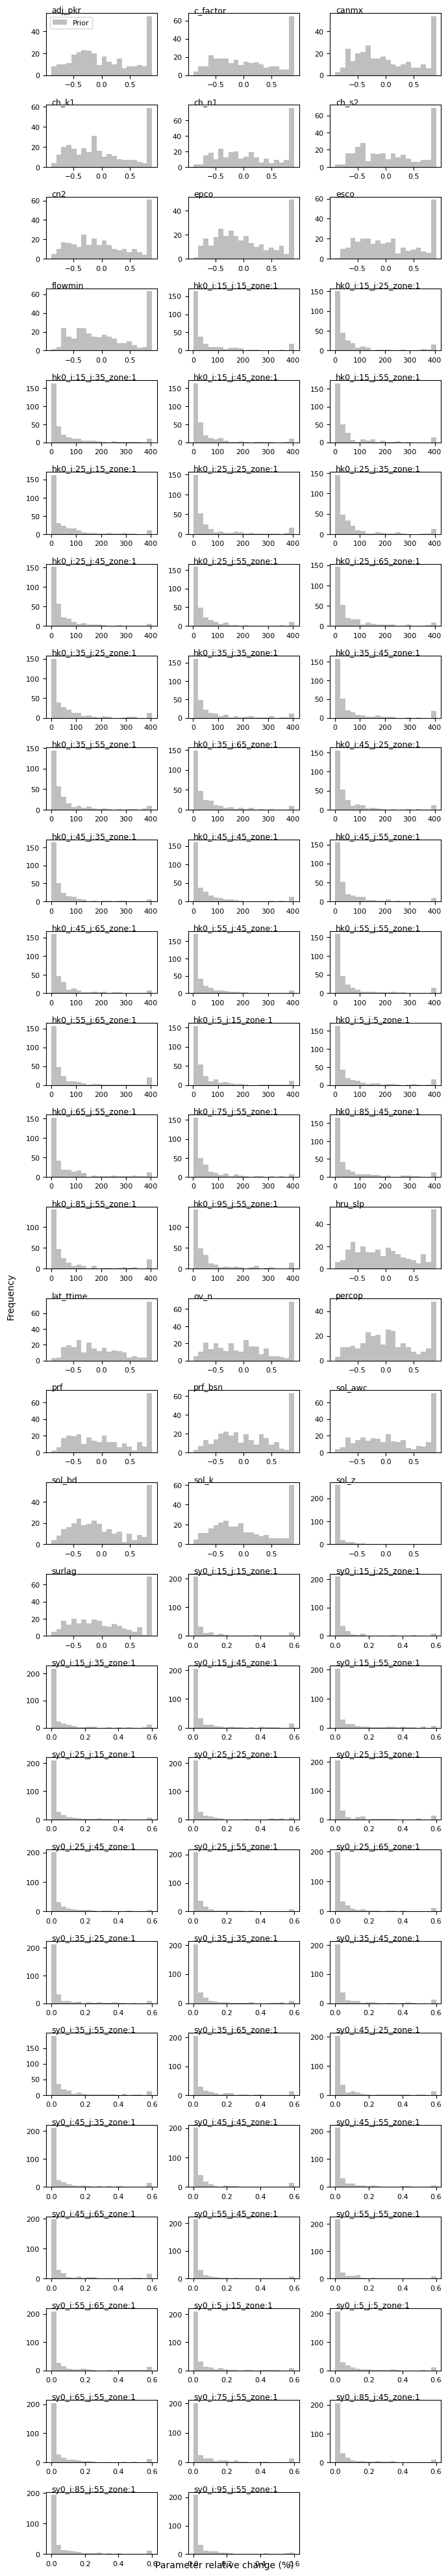

(<Figure size 700x4000 with 84 Axes>,
 array([[<Axes: title={'left': 'adj_pkr'}>,
         <Axes: title={'left': 'c_factor'}>,
         <Axes: title={'left': 'canmx'}>],
        [<Axes: title={'left': 'ch_k1'}>, <Axes: title={'left': 'ch_n1'}>,
         <Axes: title={'left': 'ch_s2'}>],
        [<Axes: title={'left': 'cn2'}>, <Axes: title={'left': 'epco'}>,
         <Axes: title={'left': 'esco'}>],
        [<Axes: title={'left': 'flowmin'}>,
         <Axes: title={'left': 'hk0_i:15_j:15_zone:1'}>,
         <Axes: title={'left': 'hk0_i:15_j:25_zone:1'}>],
        [<Axes: title={'left': 'hk0_i:15_j:35_zone:1'}>,
         <Axes: title={'left': 'hk0_i:15_j:45_zone:1'}>,
         <Axes: title={'left': 'hk0_i:15_j:55_zone:1'}>],
        [<Axes: title={'left': 'hk0_i:25_j:15_zone:1'}>,
         <Axes: title={'left': 'hk0_i:25_j:25_zone:1'}>,
         <Axes: title={'left': 'hk0_i:25_j:35_zone:1'}>],
        [<Axes: title={'left': 'hk0_i:25_j:45_zone:1'}>,
         <Axes: title={'left': 'hk0_i:

In [17]:
analyzer.ua.plot_parameter_ensemble(pst, pr_pe=pr_pe, show=True, height=40, sel_pars=sel_pars)